# Retail Sales Profitability Analysis

A portfolio project using a reproducible simulated retail sales dataset.

## Business question
Which products and locations contribute the most profit, and how does discount level relate to profit?

## Tools
Python, pandas, SQLite, SQL, and Matplotlib.

## Data note
The project includes 2,500 simulated line items generated by generate_sample_data.py. No real customer or company records are used.


## 1. Load the simulated sales data

The project includes data/sales.csv. To regenerate it, run generate_sample_data.py from the project folder.


In [1]:
from pathlib import Path
import re
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path("data") / "sales.csv"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH.resolve()}. "
        "Run generate_sample_data.py to create the included simulated dataset."
    )

raw_data = pd.read_csv(DATA_PATH)
raw_data.columns = [
    re.sub(r"[^a-z0-9]+", "_", str(c).strip().lower()).strip("_")
    for c in raw_data.columns
]
if "product" not in raw_data.columns and "product_name" in raw_data.columns:
    raw_data = raw_data.rename(columns={"product_name": "product"})
if "country" not in raw_data.columns and "country_region" in raw_data.columns:
    raw_data = raw_data.rename(columns={"country_region": "country"})

print(f"Rows loaded: {len(raw_data):,}")
print("Columns:", list(raw_data.columns))
display(raw_data.head())

Rows loaded: 2,500
Columns: ['order_id', 'order_date', 'country', 'region', 'state', 'category', 'product', 'quantity', 'sales', 'discount', 'profit']


,order_id,order_date,country,region,state,category,product,quantity,sales,discount,profit
0,ORD00001,2025-09-01,United States,West,Oregon,Technology,Printer,7,1213.81,0.00,192.29
1,ORD00002,2025-03-25,United States,East,Massachusetts,Office Supplies,Binder,2,36.90,0.00,6.60
2,ORD00003,2025-03-03,United States,West,Washington,Technology,Accessories,7,554.15,0.05,184.95
3,ORD00004,2024-01-19,United States,Central,Colorado,Office Supplies,Paper,1,24.19,0.30,0.66
4,ORD00005,2025-02-06,United States,South,Texas,Furniture,Desk,4,3474.50,0.00,609.23


## 2. Check columns and clean analysis fields

The notebook accepts Product, Product Name, Sub-Category, or Category. It selects a location field with more than one value where possible. If the sample contains only one country, state or region is more useful for comparison.

In [2]:
product_candidates = ["product", "product_name", "sub_category", "category"]
product_column = next(
    (c for c in product_candidates if c in raw_data.columns), None
)
if product_column is None:
    raise ValueError("Expected a Product, Product Name, Sub-Category, or Category column.")

missing = [c for c in ["profit", "discount"] if c not in raw_data.columns]
if missing:
    raise ValueError(f"Required columns are missing: {missing}")

location_candidates = ["state", "region", "country", "city"]
location_column = next(
    (c for c in location_candidates
     if c in raw_data.columns and raw_data[c].nunique(dropna=True) > 1),
    None,
)

clean_data = raw_data.copy()
for column in ["profit", "discount"]:
    clean_data[column] = pd.to_numeric(clean_data[column], errors="coerce")

input_rows = len(clean_data)
duplicate_rows = int(clean_data.duplicated().sum())
missing_required = int(
    clean_data[[product_column, "profit", "discount"]].isna().any(axis=1).sum()
)
clean_data = clean_data.dropna(
    subset=[product_column, "profit", "discount"]
).copy()
clean_data["analysis_product"] = clean_data[product_column].astype(str)
clean_data["analysis_location"] = (
    clean_data[location_column].fillna("Unknown").astype(str)
    if location_column else "All data"
)

quality_summary = pd.DataFrame([
    {"measure": "Input rows", "value": input_rows},
    {"measure": "Exact duplicate rows", "value": duplicate_rows},
    {"measure": "Rows missing required analysis fields", "value": missing_required},
    {"measure": "Rows retained", "value": len(clean_data)},
])
display(quality_summary)
print("Product field:", product_column)
print("Location field:", location_column or "All data")

,measure,value
0,Input rows,2500
1,Exact duplicate rows,0
2,Rows missing required analysis fields,32
3,Rows retained,2468


Product field: product
Location field: state


## 3. Query profit by location and product

Counts are line items, not orders. The discount comparison is descriptive; it cannot show that discounts caused a profit change.

In [3]:
location_sql = """
SELECT analysis_location, COUNT(*) AS line_items,
       ROUND(SUM(profit), 2) AS total_profit,
       ROUND(AVG(discount), 4) AS average_discount
FROM sales
GROUP BY analysis_location
ORDER BY total_profit DESC
"""

product_sql = """
SELECT analysis_product, COUNT(*) AS line_items,
       ROUND(SUM(profit), 2) AS total_profit,
       ROUND(AVG(discount), 4) AS average_discount
FROM sales
GROUP BY analysis_product
ORDER BY total_profit DESC
"""

with sqlite3.connect(":memory:") as connection:
    clean_data[
        ["analysis_location", "analysis_product", "profit", "discount"]
    ].to_sql("sales", connection, index=False, if_exists="replace")
    profit_by_location = pd.read_sql_query(location_sql, connection)
    profit_by_product = pd.read_sql_query(product_sql, connection)

display(profit_by_location.head(10))
display(profit_by_product.head(10))

,analysis_location,line_items,total_profit,average_discount
0,Colorado,182,36563.26,0.1121
1,Florida,174,27612.58,0.1221
2,Nevada,142,26812.09,0.0947
3,North Carolina,147,26749.27,0.1201
4,New York,173,26589.39,0.1156
5,Virginia,157,26337.99,0.1064
6,New Jersey,149,26330.50,0.1292
7,Illinois,157,24120.88,0.1182
8,Ohio,129,23896.97,0.1233
9,Georgia,153,23699.69,0.1180


,analysis_product,line_items,total_profit,average_discount
0,Laptop,203,100623.22,0.1305
1,Phone,229,80934.12,0.1192
2,Bookcase,205,38586.34,0.1198
3,Table,179,36751.38,0.1318
4,Desk,202,34368.66,0.1042
5,Chair,205,29268.63,0.1222
6,Accessories,214,26600.56,0.1217
7,Printer,213,21091.64,0.1164
8,Storage,179,12010.29,0.1327
9,Binder,219,8658.42,0.1160


## 4. Compare discount bands

Review the row count in each band before interpreting average profit.

In [4]:
clean_data["discount_band"] = pd.cut(
    clean_data["discount"],
    bins=[-float("inf"), 0, 0.10, 0.20, 0.30, float("inf")],
    labels=["No discount", "0-10%", "10-20%", "20-30%", "Above 30%"],
    include_lowest=True,
)

profit_by_discount = (
    clean_data.groupby("discount_band", observed=False)
    .agg(
        line_items=("profit", "size"),
        average_profit=("profit", "mean"),
        total_profit=("profit", "sum"),
    )
    .reset_index()
)
profit_by_discount[["average_profit", "total_profit"]] = (
    profit_by_discount[["average_profit", "total_profit"]].round(2)
)
display(profit_by_discount)

,discount_band,line_items,average_profit,total_profit
0,No discount,1006,278.71,280385.26
1,0-10%,486,189.70,92194.46
2,10-20%,542,89.96,48757.79
3,20-30%,206,-17.88,-3683.73
4,Above 30%,228,-98.86,-22540.20


## 5. Chart and export the results

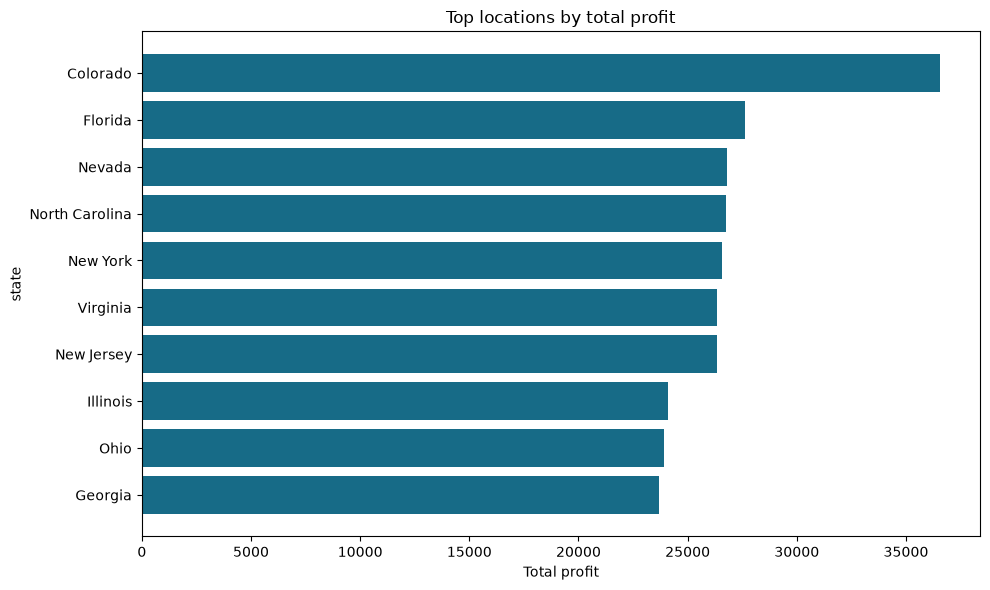

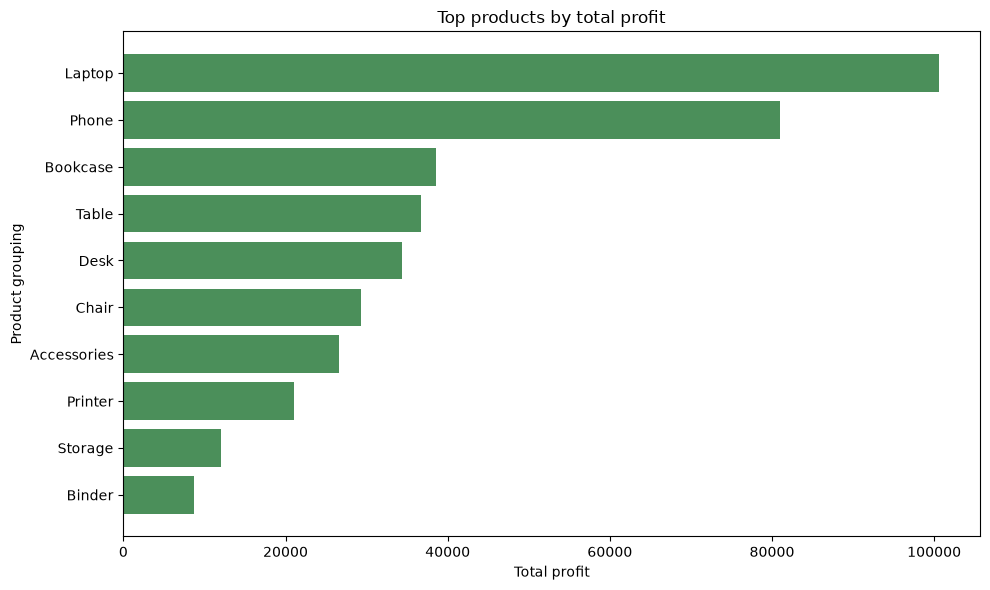

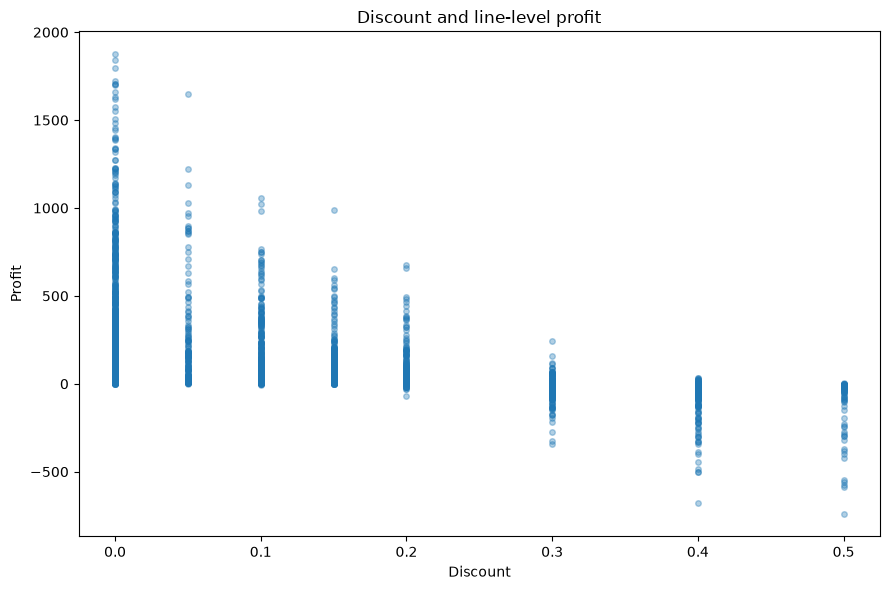

Saved tables, charts, and SQL in C:\Users\zubair.hanif\Documents\Codex\2026-10-04\i\outputs\sales_profitability_portfolio\outputs


In [5]:
location_chart = profit_by_location.head(10).sort_values("total_profit")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(location_chart["analysis_location"], location_chart["total_profit"], color="#176B87")
ax.set(title="Top locations by total profit", xlabel="Total profit",
       ylabel=location_column or "Location")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "profit_by_location.png", dpi=180, bbox_inches="tight")
plt.show()

product_chart = profit_by_product.head(10).sort_values("total_profit")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(product_chart["analysis_product"], product_chart["total_profit"], color="#4B8F5A")
ax.set(title="Top products by total profit", xlabel="Total profit",
       ylabel="Product grouping")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "profit_by_product.png", dpi=180, bbox_inches="tight")
plt.show()

scatter = clean_data[["discount", "profit"]]
if len(scatter) > 5000:
    scatter = scatter.sample(5000, random_state=42)
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(scatter["discount"], scatter["profit"], alpha=0.35, s=16)
ax.set(title="Discount and line-level profit", xlabel="Discount", ylabel="Profit")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "discount_vs_profit.png", dpi=180, bbox_inches="tight")
plt.show()

for name, table in {
    "profit_by_location": profit_by_location,
    "profit_by_product": profit_by_product,
    "profit_by_discount": profit_by_discount,
    "data_quality_summary": quality_summary,
}.items():
    table.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)

(OUTPUT_DIR / "sales_analysis.sql").write_text(
    location_sql.strip() + ";\n\n" + product_sql.strip() + ";\n",
    encoding="utf-8",
)
print(f"Saved tables, charts, and SQL in {OUTPUT_DIR.resolve()}")

## Findings from the included simulated sample

- 2,500 rows were loaded; 2,468 were retained after removing 32 rows missing a required analysis field. No exact duplicate rows were found.
- Colorado had the highest total state profit in the sample: $36,563.26 across 182 line items.
- Laptop was the highest-profit product grouping: $100,623.22 across 203 line items.
- Average line-item profit was $278.71 for no discount and -$98.86 for discounts above 30%.

High discount values intentionally reduce the profit margin in the generator, so this pattern is designed into the simulation, not a real-world discovery.

## Chart previews

The README displays SVG previews generated from these tables. Run the final chart cell to also create PNGs with Matplotlib.

## Limitations

- The data is simulated, not real company data.
- Line-item counts are not order counts.
- Discount-profit patterns are descriptive and do not prove causation.

## Before publishing

Keep the synthetic-data limitation visible in the GitHub README and CV. Run every cell in a Python environment with the packages in requirements.txt to regenerate the PNG charts.
